# analysis.diversity

This notebook is aimed to compute:
- Alpha-Diversity according to different metrics (species richness and Chao1)
- Statistical differences between habitats and disturbance levels
- Post hoc analysis

Additionally, this notebook also creates the inputs for a correlation analysis carried out later.


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from daforfer import DaforferDB
from skbio.diversity.alpha import chao1
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                name                │                                                                                  description                                                                                   │
│              varchar               │                                                                                    varchar                                                                                     │
├────────────────────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_bacteriaHits                     │ This table contains all the MOTUS hits obtained, regardless of their status. It contains the libr

## PAB Diversity estimations


### Calculations

In [47]:
metadata = db.conn.sql('SELECT * FROM D_sites').df()
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
bacteria_hits

,site,library,habitat,n_extracts,host_taxon,taxid,scientific_name,is_pab,pab_type
1,C1,PV535,Crop,17,Brassica oleracea,1563157,Pseudomonas endophytica,True,pab_unknown
2,C1,PV535,Crop,17,Brassica oleracea,1270,Micrococcus luteus,True,pab_unknown
5,C1,PV544,Crop,4,Sisymbrium runcinatum,1735685,Sphingomonas sp. Leaf20,True,pab_unknown
6,C1,PV544,Crop,4,Sisymbrium runcinatum,1828,Rhodococcoides fascians,True,pab_unknown
7,C1,PV544,Crop,4,Sisymbrium runcinatum,1735683,Sphingomonas sp. Leaf17,True,pab_unknown
...,...,...,...,...,...,...,...,...,...
626,Z2,PV527,Crop,4,Convolvulus arvensis,1770058,Devosia elaeis,True,pab_unknown
627,Z2,PV529,Crop,1,Picris echioides,47880,Pseudomonas fulva,True,pab_unknown
628,Z2,PV529,Crop,1,Picris echioides,1220495,Pseudomonas punonensis,True,pab_unknown
629,Z2,PV529,Crop,1,Picris echioides,289370,Pseudomonas argentinensis,True,pab_unknown


We simply create a list of item counts in one of the columns. 

In [48]:
alpha_diversity = bacteria_hits.value_counts(
    ['site', 'habitat', 'taxid']
    ).reset_index().groupby(
        ['site', 'habitat']
    )['count'].apply(list).reset_index().rename(columns={'count': 'hits'})
alpha_diversity

,site,habitat,hits
0,C1,Crop,"[1, 1, 1, 1, 1, 1]"
1,C2,Crop,"[2, 1, 1, 1, 1, 1, 1, 1]"
2,E1,Wasteland,"[2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
3,E2,Wasteland,"[3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
4,E3,Wasteland,"[5, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
5,E4,Wasteland,"[8, 4, 4, 4, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, ..."
6,H1,Crop,[1]
7,H2,Crop,[1]
8,H3,Crop,"[1, 1, 1, 1]"
9,L1,Edge,"[3, 3, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [49]:
alpha_diversity['species_richness'] = alpha_diversity['hits'].apply(lambda x: len(x))
alpha_diversity['chao1'] = alpha_diversity['hits'].apply(chao1)
alpha_diversity = alpha_diversity.sort_values(by=['habitat', 'site'])
alpha_diversity['disturbed'] = alpha_diversity['habitat'].apply(
    lambda x: {"Crop": "disturbed", "Wasteland": "non-disturbed", "Edge": "disturbed", "Oak": "non-disturbed"}[x]
)
alpha_diversity = alpha_diversity.drop(columns=['hits'])[['site', 'habitat', 'disturbed', 'species_richness', 'chao1']]

db.save_dataframe(
    alpha_diversity, "D_PABAlphaDiv",
    description="Alpha Diversity Chao1 and Species Richness in Plant-Associated Bacteria"
)
alpha_diversity

Saved D_PABAlphaDiv to 2025-10-21


,site,habitat,disturbed,species_richness,chao1
0,C1,Crop,disturbed,6,21.000000
1,C2,Crop,disturbed,8,18.500000
6,H1,Crop,disturbed,1,1.000000
7,H2,Crop,disturbed,1,1.000000
8,H3,Crop,disturbed,4,10.000000
13,M1,Crop,disturbed,2,2.000000
14,M2,Crop,disturbed,1,1.000000
15,M3,Crop,disturbed,2,3.000000
16,M4,Crop,disturbed,1,1.000000
21,Z1,Crop,disturbed,11,33.500000


### Species richness results

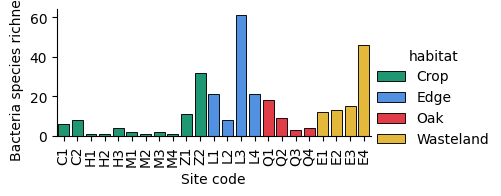

In [50]:
g = sns.catplot(alpha_diversity, x='site', y='species_richness', height=2.0, aspect=2.0, kind='bar', hue='habitat', palette=conf['habitat_palette'], edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Bacteria species richness")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)
g.savefig("figures/barplot.species-richness.colbyhabitat.svg")

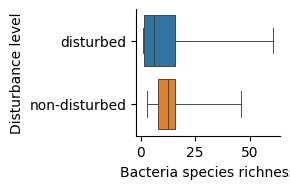

In [51]:
g = sns.catplot(
    alpha_diversity, y='disturbed', x='species_richness', height=2.0, aspect=1.50, linewidth=0.65, kind='box', hue='disturbed', whis=20.0)
g.set_xlabels("Bacteria species richness")
g.set_ylabels("Disturbance level")
g.savefig("figures/boxplot.species-richness.bydisturbance.svg")

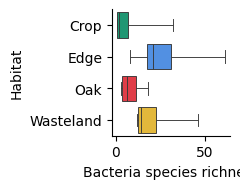

In [52]:
g = sns.catplot(
    alpha_diversity, y='habitat', x='species_richness', height=2.0, aspect=1.25, 
    hue='habitat', palette=conf['habitat_palette'], linewidth=0.65, kind='box', whis=20.0)
g.set_xlabels("Bacteria species richness")
g.set_ylabels("Habitat")
g.savefig("figures/boxplot.species-richness.byhabitat.svg")

### Chao1 diversity results 

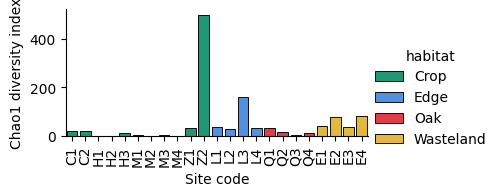

In [53]:
g = sns.catplot(alpha_diversity, x='site', y='chao1', height=2.0, aspect=2.0, kind='bar', hue='habitat', palette=conf['habitat_palette'], edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Chao1 diversity index")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)
g.savefig("figures/barplot.chao1.colbyhabitat.svg")

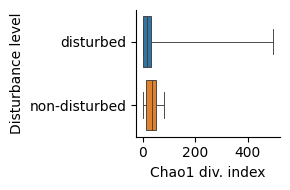

In [54]:
g = sns.catplot(
    alpha_diversity, y='disturbed', x='chao1', height=2.0, aspect=1.50, linewidth=0.65, kind='box', hue='disturbed', whis=20.0)
g.set_xlabels("Chao1 div. index")
g.set_ylabels("Disturbance level")
g.savefig("figures/boxplot.chao1.bydisturbance.svg")

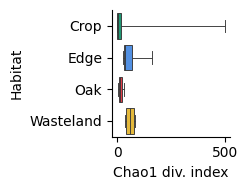

In [55]:
g = sns.catplot(
    alpha_diversity, y='habitat', x='chao1', height=2.0, aspect=1.25, 
    hue='habitat', palette=conf['habitat_palette'], linewidth=0.65, kind='box', whis=200.0)
g.set_xlabels("Chao1 div. index")
g.set_ylabels("Habitat")
g.savefig("figures/boxplot.chao1.byhabitat.svg")

### Diversity by disturbance level

In [56]:
q1_stats = []
for metric in ['species_richness', 'chao1']:
    kw_h, pval = stats.kruskal(
        alpha_diversity.query('habitat == "Crop" or habitat == "Edge"')[metric].values,
        alpha_diversity.query('habitat == "Wasteland" or habitat == "Oak"')[metric].values,
    )
    significative = pval < 0.05
    q1_stats.append(
        {'metric': metric, 'H': kw_h, 'p-val': pval, 'sign': significative}
    )
q1_stats = pd.DataFrame.from_records(q1_stats)

db.save_dataframe(
    df=q1_stats, table_name="T_ADDisturbance",
    description="Mann Whitney U test on species richness and Chao1 diversity index by disturbance level"
)
q1_stats

Saved T_ADDisturbance to 2025-10-21


,metric,H,p-val,sign
0,species_richness,1.763238,0.184221,False
1,chao1,2.120902,0.145301,False


### Diversity by habitat

In [57]:
q2_stats = []
for metric in ['species_richness', 'chao1']:
    kw_h, pval = stats.kruskal(
        alpha_diversity.query('habitat == "Crop"')[metric].values,
        alpha_diversity.query('habitat == "Edge"')[metric].values,
        alpha_diversity.query('habitat == "Wasteland"')[metric].values,
        alpha_diversity.query('habitat == "Oak"')[metric].values
    )
    significative = pval < 0.05
    q2_stats.append(
        {'metric': metric, 'H': kw_h, 'p-val': pval, 'sign': significative}
    )
q2_stats = pd.DataFrame.from_records(q2_stats)

db.save_dataframe(
    df=q2_stats, table_name="T_ADhabitat",
    description="Kruskal Wallis test on species richness and Chao1 diversity index by habitat"
)
q2_stats

Saved T_ADhabitat to 2025-10-21


,metric,H,p-val,sign
0,species_richness,10.430597,0.015239,True
1,chao1,11.000373,0.011724,True


### Diversity by habitat, post-hoc analysis

In [58]:
q3_stats = []
for metric in ['species_richness', 'chao1']:
    for h1 in ['Crop', 'Edge', 'Wasteland', 'Oak']:
        for h2 in ['Crop', 'Edge', 'Wasteland', 'Oak']:
            if h1 != h2:
                kw_h, pval = stats.mannwhitneyu(
                    alpha_diversity.query('habitat == "{0}"'.format(h1))[metric].values,
                    alpha_diversity.query('habitat == "{0}"'.format(h2))[metric].values,
                )
                significative = pval < 0.05
                q3_stats.append(
                    {'metric': metric, 'group_1': h1, 'group_2': h2, 'H': kw_h, 'p-val': pval, 'sign': significative}
                )
q3_stats_df = pd.DataFrame.from_records(q3_stats)

db.save_dataframe(
    df=q3_stats_df, table_name="T_ADHabitatPH",
    description="Post-Hoc Mann Whitney U analysis on species richness and Chao1 diversity index by habitat"
)

q3_stats_df

Saved T_ADHabitatPH to 2025-10-21


,metric,group_1,group_2,H,p-val,sign
0,species_richness,Crop,Edge,4.5,0.024723,True
1,species_richness,Crop,Wasteland,3.0,0.014711,True
2,species_richness,Crop,Oak,12.5,0.234904,False
3,species_richness,Edge,Crop,39.5,0.024723,True
4,species_richness,Edge,Wasteland,10.0,0.663117,False
5,species_richness,Edge,Oak,14.0,0.110210,False
6,species_richness,Wasteland,Crop,41.0,0.014711,True
7,species_richness,Wasteland,Edge,6.0,0.663117,False
8,species_richness,Wasteland,Oak,13.0,0.200000,False
9,species_richness,Oak,Crop,31.5,0.234904,False


In [59]:
q3_stats_df.query('metric == "species_richness"').pivot(index='group_1', columns='group_2', values='p-val')

group_2,Crop,Edge,Oak,Wasteland
group_1,,,,
Crop,NaN,0.024723,0.234904,0.014711
Edge,0.024723,NaN,0.110210,0.663117
Oak,0.234904,0.110210,NaN,0.200000
Wasteland,0.014711,0.663117,0.200000,NaN


In [60]:
q3_stats_df.query('metric == "species_richness"').pivot(index='group_1', columns='group_2', values='H')

group_2,Crop,Edge,Oak,Wasteland
group_1,,,,
Crop,NaN,4.5,12.5,3.0
Edge,39.5,NaN,14.0,10.0
Oak,31.5,2.0,NaN,3.0
Wasteland,41.0,6.0,13.0,NaN


## PAB Diversity correlation with Plant diversity at habitat and site level

### Site level

In [61]:
# bacteria_hits = pd.read_csv("output/hits.bacteria.csv", sep=";").query("is_pab==True")
# bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
# bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
# bacteria_alpha_diversity = bacteria_hits.value_counts(
#     ['site', 'habitat', 'taxid', 'gtdb_genome_representative']
#     ).reset_index().groupby(
#         ['site', 'habitat']
#     )['count'].apply(list).reset_index().rename(columns={'count': 'hits'})
# bacteria_alpha_diversity['species_richness'] = bacteria_alpha_diversity['hits'].apply(lambda x: len(x))
# bacteria_alpha_diversity

In [62]:
# virus_hits = pd.read_csv("output/hits.virus.csv", sep=";")
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()
virus_hits = pd.merge(metadata, virus_hits, on='library', how='left').dropna(subset='taxid')
virus_hits['taxid'] = virus_hits['taxid'].astype(int)
virus_alpha_diversity = virus_hits.value_counts(
    ['site', 'habitat', 'taxid']
    ).reset_index().groupby(
        ['site', 'habitat']
    )['count'].apply(list).reset_index().rename(columns={'count': 'hits'})
virus_alpha_diversity['species_richness'] = virus_alpha_diversity['hits'].apply(lambda x: len(x))
virus_alpha_diversity


,site,habitat,hits,species_richness
0,C1,Crop,"[5, 3, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, ...",18
1,C2,Crop,"[3, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1]",12
2,E1,Wasteland,"[5, 4, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1]",13
3,E2,Wasteland,"[8, 4, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",30
4,E3,Wasteland,"[5, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",17
5,E4,Wasteland,"[13, 10, 9, 6, 4, 3, 3, 2, 2, 1, 1, 1, 1, 1, 1...",26
6,H1,Crop,"[3, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1]",12
7,H2,Crop,"[3, 3, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1]",12
8,H3,Crop,"[3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, ...",33
9,L1,Edge,"[37, 30, 25, 14, 14, 13, 12, 11, 11, 10, 6, 6,...",53


In [63]:
plant_hits = pd.read_csv("input/hits.plant.csv", sep=';', header=None, names=['Code', 'Species name']).dropna()
plant_hits['Collection_code'] = plant_hits['Code'].apply(lambda x: x.split('.')[0])
plant_hits['position'] = plant_hits['Code'].apply(lambda x: int(x.split('.')[1]))
plant_hits = pd.merge(
    pd.read_csv("input/mcleish24.TableS1.csv", sep=';'), plant_hits, on='Collection_code',
    how='left'
)
plant_hits = plant_hits[['Site_code', 'Species name']].drop_duplicates(['Site_code', 'Species name']).rename(columns={'Site_code': 'site'})
plant_hits = pd.merge(
    metadata[['site', 'habitat']].drop_duplicates(['site', 'habitat'], keep='first'), 
    plant_hits, on='site', how='left'
).dropna(subset='Species name')
plant_alpha_diversity = plant_hits.value_counts(
    ['site', 'habitat', 'Species name']
    ).reset_index().groupby(
        ['site', 'habitat']
    )['count'].apply(list).reset_index().rename(columns={'count': 'hits'})
plant_alpha_diversity['species_richness'] = plant_alpha_diversity['hits'].apply(lambda x: len(x))
plant_alpha_diversity

,site,habitat,hits,species_richness
0,C1,Crop,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",16
1,C2,Crop,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",22
2,E1,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",46
3,E2,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",56
4,E3,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",58
5,E4,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",46
6,H1,Crop,"[1, 1, 1, 1, 1, 1]",6
7,H2,Crop,"[1, 1, 1, 1, 1]",5
8,H3,Crop,"[1, 1, 1, 1, 1, 1, 1, 1, 1]",9
9,L1,Edge,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",36


In [64]:
host_alpha_diversity = metadata.value_counts(
    ['site', 'habitat', 'host_taxon']
).reset_index().groupby(
    ['site', 'habitat']
)['count'].apply(list).reset_index().rename(columns={'count': 'hits'})
host_alpha_diversity['species_richness'] = host_alpha_diversity['hits'].apply(lambda x: len(x))
host_alpha_diversity

,site,habitat,hits,species_richness
0,C1,Crop,"[2, 1, 1, 1]",4
1,C2,Crop,"[2, 1, 1, 1, 1]",5
2,E1,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",14
3,E2,Wasteland,"[2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",18
4,E3,Wasteland,"[2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",13
5,E4,Wasteland,"[2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",18
6,H1,Crop,"[2, 1, 1]",3
7,H2,Crop,"[2, 1, 1]",3
8,H3,Crop,"[2, 1, 1, 1]",4
9,L1,Edge,"[3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, ...",28


In [65]:
bacteria_alpha_diversity = db.conn.query('SELECT * FROM D_PABAlphaDiv').df()
alpha_diversity = pd.merge(
    bacteria_alpha_diversity[['site', 'habitat', 'species_richness']], 
    virus_alpha_diversity[['site', 'species_richness']],
    on='site', suffixes=['_bact', '_vir']
)

alpha_diversity = pd.merge(
    alpha_diversity,
    plant_alpha_diversity[['site', 'species_richness']].rename(columns={'species_richness': 'species_richness_plant'}),
    on='site'
)

alpha_diversity = pd.merge(
    alpha_diversity,
    host_alpha_diversity[['site', 'species_richness']].rename(columns={'species_richness': 'species_richness_host'}),
    on='site'
)
alpha_diversity['disturbed'] = alpha_diversity['habitat'].apply(
    lambda x: {'Crop': True, 'Wasteland': False, 'Edge': True, 'Oak': False}[x]
)

alpha_diversity.to_csv("output/diversity.all.csv", sep=";", index=False)
db.save_dataframe(
    df=alpha_diversity, table_name="D_ADAllOrganismsSite",
    description="Alpha diversity per site for virus, plant, host and bacteria at site level"
)

alpha_diversity

Saved D_ADAllOrganismsSite to 2025-10-21


,site,habitat,species_richness_bact,species_richness_vir,species_richness_plant,species_richness_host,disturbed
0,C1,Crop,6,18,16,4,True
1,C2,Crop,8,12,22,5,True
2,H1,Crop,1,12,6,3,True
3,H2,Crop,1,12,5,3,True
4,H3,Crop,4,33,9,4,True
5,M1,Crop,2,19,14,5,True
6,M2,Crop,1,12,9,4,True
7,M3,Crop,2,9,11,4,True
8,M4,Crop,1,8,15,3,True
9,Z1,Crop,11,12,13,6,True


### Habitat level

In [66]:
plant_alpha_diversity = plant_hits.value_counts(
    ['habitat', 'Species name']
    ).reset_index().groupby(
        ['habitat']
    )['count'].apply(list).reset_index().rename(columns={'count': 'hits'})
plant_alpha_diversity['species_richness'] = plant_alpha_diversity['hits'].apply(lambda x: len(x))

virus_alpha_diversity = virus_hits.value_counts(
    ['habitat', 'taxid']
    ).reset_index().groupby(
        ['habitat']
    )['count'].apply(list).reset_index().rename(columns={'count': 'hits'})
virus_alpha_diversity['species_richness'] = virus_alpha_diversity['hits'].apply(lambda x: len(x))


bacteria_alpha_diversity = bacteria_hits.value_counts(
    ['habitat', 'taxid']
    ).reset_index().groupby(
        ['habitat']
    )['count'].apply(list).reset_index().rename(columns={'count': 'hits'})
bacteria_alpha_diversity['species_richness'] = bacteria_alpha_diversity['hits'].apply(lambda x: len(x))

alpha_diversity = pd.merge(
    bacteria_alpha_diversity[['habitat', 'species_richness']], 
    virus_alpha_diversity[['habitat', 'species_richness']],
    on='habitat', suffixes=['_bact', '_vir']
)

alpha_diversity = pd.merge(
    alpha_diversity,
    plant_alpha_diversity[['habitat', 'species_richness']].rename(columns={'species_richness': 'species_richness_plant'}),
    on='habitat'
)

alpha_diversity['disturbed'] = alpha_diversity['habitat'].apply(
    lambda x: {'Crop': True, 'Wasteland': False, 'Edge': True, 'Oak': False}[x]
)

db.save_dataframe(
    df=alpha_diversity, table_name="D_ADAllOrganismsHab",
    description="Alpha diversity per site for virus, plant, host and bacteria at habitat level"
)

alpha_diversity.to_csv("output/diversity-by-habitat.all.csv", sep=";", index=False)

Saved D_ADAllOrganismsHab to 2025-10-21


In [67]:
db.conn.close()